In [36]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


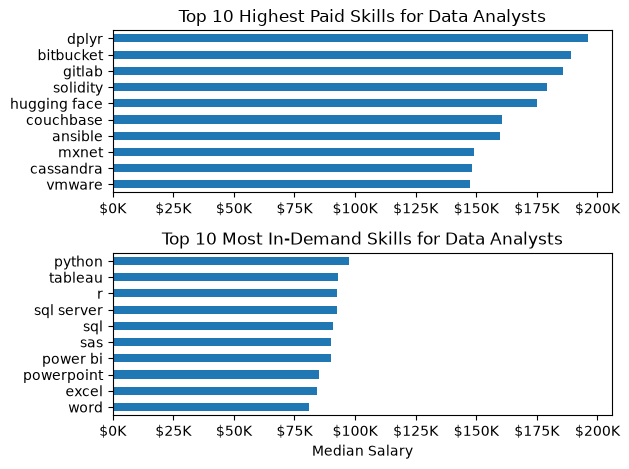

In [ ]:
# df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()
# df_DA_US = df_DA_US.explode('job_skills')
# df_DA_US.dropna(subset='salary_year_avg', inplace=True)
# df_grouped = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median', 'count'])
# df_salary = df_grouped.sort_values(by='median', ascending=False).head(10)
# df_skills = df_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

# fig, ax = plt.subplots(2,1)

# df_salary[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
# ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
# ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
# ax[0].set_ylabel('')

# df_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
# ax[1].set_xlim(ax[0].get_xlim())
# ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
# ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
# ax[1].set_ylabel('')
# ax[1].set_xlabel('Median Salary')

# fig.tight_layout()



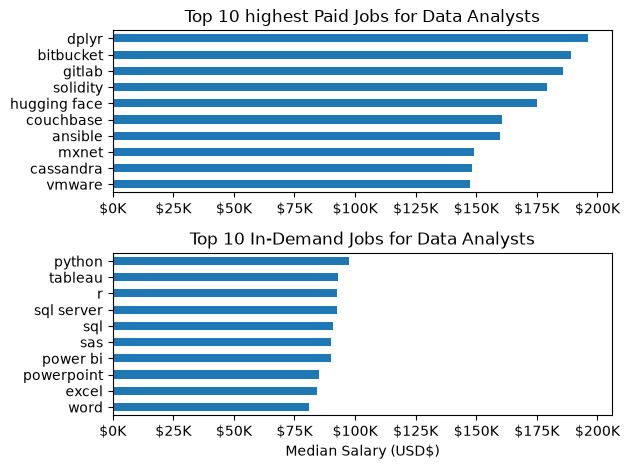

In [52]:
df_DA_US = df[(df['job_title_short']=='Data Analyst')&(df['job_country']=='United States')].copy()
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US.dropna(subset='salary_year_avg', inplace=True)

df_grouped = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median','count'])
df_salary = df_grouped.sort_values(by='median', ascending=False).head(10)
df_skills = df_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

fig, ax = plt.subplots(2,1)

df_salary[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[0].set_title('Top 10 highest Paid Jobs for Data Analysts')
ax[0].set_ylabel('')

df_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[1].set_title('Top 10 In-Demand Jobs for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD$)')

fig.tight_layout()